In [ ]:
!unzip data_tensor_2.pt.zip

Archive:  data_tensor_2.pt.zip
  inflating: data_tensor_2.pt        
replace __MACOSX/._data_tensor_2.pt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
!pip install wandb

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, random_split
from torch.optim import AdamW
from transformers import BertConfig, BertModel, get_linear_schedule_with_warmup

import numpy as np
from tqdm import tqdm
import os

# --- Import and check for Weights & Biases ---
try:
    import wandb
    WANDB_AVAILABLE = True
except ImportError:
    print("Warning: wandb library not found. Disabling logging. Please pip install wandb.")
    WANDB_AVAILABLE = False

# =================================================================
# 1. CONFIGURATION
# =================================================================
hyperparameter_config = {
    "data_file_path": "data_tensor_2.pt",
    "epochs": 10,
    "batch_size": 1024,
    "learning_rate": 5e-5,
    "hidden_size": 256,
    "num_layers": 4,
    "num_attention_heads": 4,
    "intermediate_size": 1024,
    "warmup_ratio": 0.1,
    "train_split_ratio": 0.9,
    "weight_decay": 0.1,
    "log_frequency": 50,  # <-- NEW: Log metrics every 50 training steps
    "project_name": "moral-transformer-project",
    "run_name": f"run_{torch.cuda.initial_seed() if torch.cuda.is_available() else 'cpu'}_{int(np.random.rand()*1000)}",
}

# --- Data & Vocabulary ---
FEATURES = [
    'Intervention', 'Barrier', 'CrossingSignal', 'Man', 'Woman',
    'Pregnant', 'Stroller', 'OldMan', 'OldWoman', 'Boy', 'Girl', 'Homeless',
    'LargeWoman', 'LargeMan', 'Criminal', 'MaleExecutive', 'FemaleExecutive',
    'FemaleAthlete', 'MaleAthlete', 'FemaleDoctor', 'MaleDoctor', 'Dog', 'Cat'
]
SPECIAL_TOKENS = ['[PAD]', '[CLS]', '[SEP]']
VOCAB = SPECIAL_TOKENS + FEATURES
FEATURE_TO_ID = {feature: i for i, feature in enumerate(VOCAB)}
VOCAB_SIZE = len(VOCAB)
PAD_TOKEN_ID = FEATURE_TO_ID['[PAD]']
CLS_TOKEN_ID = FEATURE_TO_ID['[CLS]']
SEP_TOKEN_ID = FEATURE_TO_ID['[SEP]']

# --- System Setup ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =================================================================
# 2. DATA HANDLING (Dataset & DataLoader)
# =================================================================
class MoralMachineDataset(Dataset):
    """Custom PyTorch Dataset for the pre-processed and balanced Moral Machine data."""
    def __init__(self, data_matrix, labels):
        self.X = data_matrix
        self.y = labels

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        scenario_a, scenario_b, label = self.X[idx, 0, :], self.X[idx, 1, :], self.y[idx]
        tokens_a = [i + len(SPECIAL_TOKENS) for i, feat_val in enumerate(scenario_a) if feat_val != 0]
        tokens_b = [i + len(SPECIAL_TOKENS) for i, feat_val in enumerate(scenario_b) if feat_val != 0]
        input_ids = [CLS_TOKEN_ID] + tokens_a + [SEP_TOKEN_ID] + tokens_b + [SEP_TOKEN_ID]
        return {'input_ids': torch.tensor(input_ids, dtype=torch.long), 'label': torch.tensor(label, dtype=torch.float)}

def create_collate_fn(pad_token_id):
    """Creates a collate function to handle padding for dynamic batching."""
    def collate_fn(batch):
        input_ids_list = [item['input_ids'] for item in batch]
        labels = torch.stack([item['label'] for item in batch])
        padded_input_ids = torch.nn.utils.rnn.pad_sequence(input_ids_list, batch_first=True, padding_value=pad_token_id)
        attention_mask = (padded_input_ids != pad_token_id).type(torch.long)
        return {'input_ids': padded_input_ids, 'attention_mask': attention_mask, 'labels': labels}
    return collate_fn

# =================================================================
# 3. MODEL DEFINITION
# =================================================================
class MoralTransformer(nn.Module):
    """Transformer model for moral choice comparison."""
    def __init__(self, config):
        super().__init__()
        self.transformer = BertModel(config)
        self.output_head = nn.Linear(config.hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden_state = outputs.last_hidden_state
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
        sum_embeddings = torch.sum(last_hidden_state * input_mask_expanded, 1)
        sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
        pooled_output = sum_embeddings / sum_mask
        logits = self.output_head(pooled_output)
        return logits.squeeze(-1)

# =================================================================
# 4. TRAINING & EVALUATION FUNCTIONS
# =================================================================
def train_epoch(model, dataloader, optimizer, scheduler, loss_fn, device, epoch, log_freq, global_step):
    model.train()
    total_loss = 0
    for i, batch in enumerate(tqdm(dataloader, desc=f"Training Epoch {epoch}")):
        input_ids, attention_mask, labels = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['labels'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()

        batch_loss = loss.item()
        total_loss += batch_loss

        # --- Per-Step Logging ---
        if WANDB_AVAILABLE and (i + 1) % log_freq == 0:
            wandb.log({
                "step_train_loss": batch_loss,
                "learning_rate": scheduler.get_last_lr()[0],
                "global_step": global_step
            })

        global_step += 1

    return total_loss / len(dataloader), global_step

def evaluate(model, dataloader, loss_fn, device):
    model.eval()
    total_loss, correct_predictions, total_samples = 0, 0, 0
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids, attention_mask, labels = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['labels'].to(device)
            logits = model(input_ids, attention_mask)
            loss = loss_fn(logits, labels)
            preds = (torch.sigmoid(logits) > 0.5).long()
            total_loss += loss.item()
            correct_predictions += (preds == labels.long()).sum().item()
            total_samples += labels.size(0)
    return total_loss / len(dataloader), correct_predictions / total_samples



In [ ]:
# =================================================================
# 5. MAIN EXECUTION BLOCK
# =================================================================
if __name__ == "__main__":
    if WANDB_AVAILABLE:
        wandb.init(project=hyperparameter_config["project_name"], name=hyperparameter_config["run_name"], config=hyperparameter_config)
        config = wandb.config
    else:
        config = hyperparameter_config # Use the dictionary directly if wandb is not available

    print(f"Using device: {DEVICE}")
    print(f"Vocabulary size: {VOCAB_SIZE}")

    # --- Load and Process Data ---
    if not os.path.exists(config.data_file_path):
        raise FileNotFoundError(f"Data file not found at '{config.data_file_path}'. Please update the path.")

    original_data_tensor = torch.load(config.data_file_path, map_location='cpu')
    original_data_numpy = original_data_tensor.numpy()

    print(f"Original data matrix shape: {original_data_numpy.shape}")
    assert original_data_numpy.shape[-1] == len(FEATURES), f"Data dimension mismatch: expected {len(FEATURES)}, found {original_data_numpy.shape[-1]}"

    num_original_samples = original_data_numpy.shape[0]
    original_labels = np.zeros(num_original_samples)
    swapped_data = original_data_numpy[:, [1, 0], :]
    swapped_labels = np.ones(num_original_samples)
    final_data = np.concatenate([original_data_numpy, swapped_data], axis=0)
    final_labels = np.concatenate([original_labels, swapped_labels], axis=0)
    print(f"Final balanced data matrix shape: {final_data.shape}")

    # --- Setup Dataset and DataLoaders ---
    dataset = MoralMachineDataset(final_data, final_labels)
    train_size = int(config.train_split_ratio * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    collate = create_collate_fn(PAD_TOKEN_ID)
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, collate_fn=collate, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=config.batch_size, collate_fn=collate)

    # --- Initialize Model, Optimizer, etc. ---
    print("\nInitializing model...")
    bert_config = BertConfig(
        vocab_size=VOCAB_SIZE, hidden_size=config.hidden_size, num_hidden_layers=config.num_layers,
        num_attention_heads=config.num_attention_heads, intermediate_size=config.intermediate_size,
        pad_token_id=PAD_TOKEN_ID,
    )
    model = MoralTransformer(bert_config).to(DEVICE)
    if WANDB_AVAILABLE:
        wandb.watch(model, log_freq=100)

    optimizer = AdamW(model.parameters(), lr=config.learning_rate)
    total_steps = len(train_loader) * config.epochs
    warmup_steps = int(config.warmup_ratio * total_steps)
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)
    loss_fn = nn.BCEWithLogitsLoss()

    # --- Training Loop ---
    print("\nStarting training...")
    global_step = 0
    for epoch in range(config.epochs):
        avg_train_loss, global_step = train_epoch(model, train_loader, optimizer, scheduler, loss_fn, DEVICE, epoch + 1, config.log_frequency, global_step)
        val_loss, val_accuracy = evaluate(model, val_loader, loss_fn, DEVICE)

        print(f"--- End of Epoch {epoch + 1}/{config.epochs} ---")
        print(f"Average Training Loss: {avg_train_loss:.4f}")
        print(f"Validation Loss: {val_loss:.4f} | Validation Accuracy: {val_accuracy:.4f}")

        # Log summary metrics to Weights & Biases at the end of each epoch
        if WANDB_AVAILABLE:
            wandb.log({
                "epoch": epoch + 1,
                "avg_train_loss": avg_train_loss,
                "val_loss": val_loss,
                "val_accuracy": val_accuracy
            })

    print("\nTraining complete.")
    if WANDB_AVAILABLE:
        wandb.finish()

    print("Model ready.")

Using device: cuda
Vocabulary size: 26
Original data matrix shape: (1749370, 2, 23)
Final balanced data matrix shape: (3498740, 2, 23)

Initializing model...

Starting training...


Evaluating: 100%|██████████| 342/342 [00:23<00:00, 14.66it/s]


--- End of Epoch 1/10 ---
Average Training Loss: 0.5502
Validation Loss: 0.5091 | Validation Accuracy: 0.7693


Evaluating: 100%|██████████| 342/342 [00:23<00:00, 14.39it/s]


--- End of Epoch 2/10 ---
Average Training Loss: 0.5074
Validation Loss: 0.5045 | Validation Accuracy: 0.7702


...

--- End of Epoch 6/10 ---
Average Training Loss: 0.5030
Validation Loss: 0.5025 | Validation Accuracy: 0.7706


Evaluating: 100%|██████████| 342/342 [00:23<00:00, 14.42it/s]


--- End of Epoch 7/10 ---
Average Training Loss: 0.5027
Validation Loss: 0.5021 | Validation Accuracy: 0.7711


Training Epoch 8:   3%|▎         | 85/3076 [00:13<08:02,  6.20it/s]


KeyboardInterrupt: 

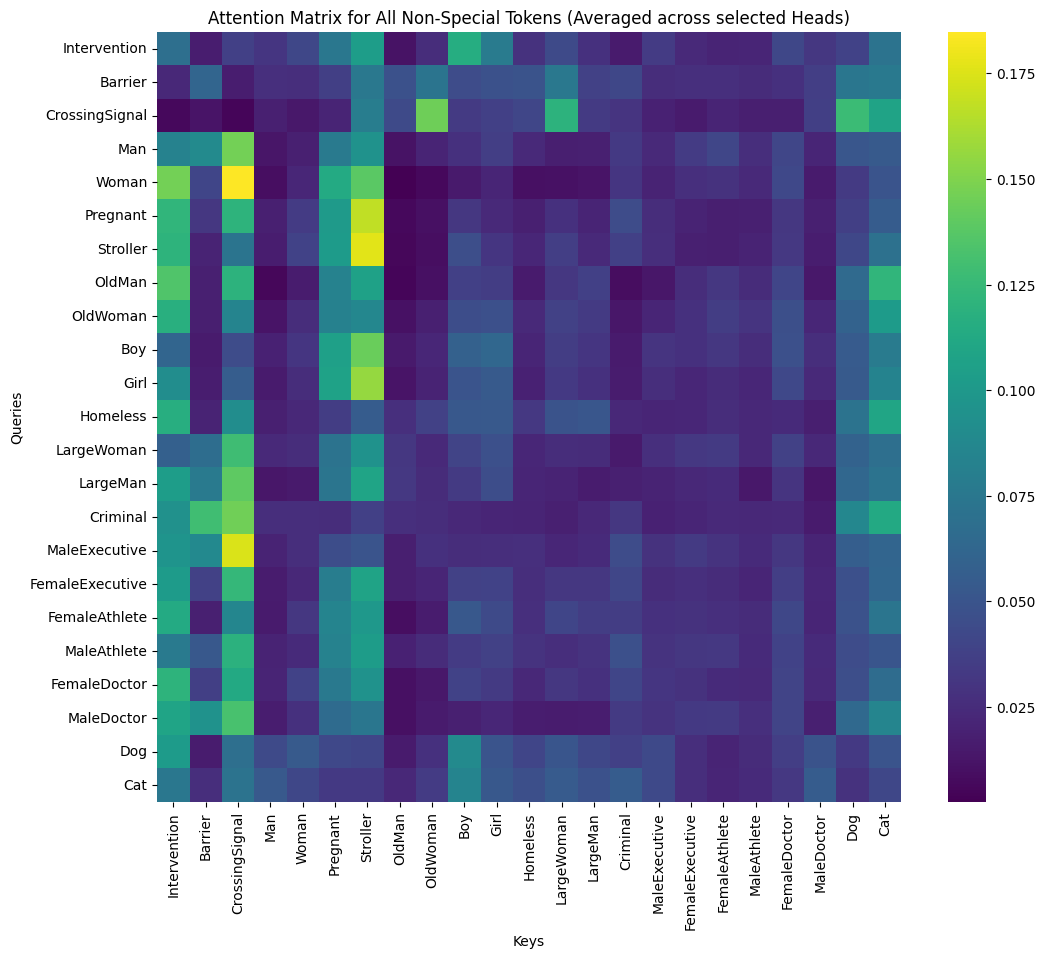

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from tqdm import tqdm

def get_attention_weights_all_tokens(model, feature_to_id, device):
    """Extracts attention weights for sequences containing all non-special tokens."""
    model.eval()
    id_to_feature = {v: k for k, v in feature_to_id.items()}
    non_special_token_ids = [feature_to_id[feature] for feature in FEATURE_TO_ID if not feature.startswith('[')]
    # Create a sequence with all non-special tokens
    input_ids = torch.tensor([non_special_token_ids], dtype=torch.long).to(device)
    attention_mask = torch.ones_like(input_ids).to(device)

    with torch.no_grad():
        outputs = model.transformer(input_ids=input_ids, attention_mask=attention_mask, output_attentions=True)
        # Attention weights are usually in the last layer
        attention_weights = outputs.attentions[-1] # Shape: (batch_size, num_heads, sequence_length, sequence_length)

    return attention_weights[0] # Return attention for the single batch item


def visualize_attention_all_tokens(attention_weights, feature_to_id, vocab, num_heads=1):
    """Visualizes the attention matrix for all non-special tokens."""
    attention = attention_weights  # Shape: (num_heads, sequence_length, sequence_length)

    # Select attention from a few heads or average
    if num_heads > 1:
        attention = attention[:num_heads].mean(dim=0) # Average over selected heads
    else:
        attention = attention[0] # Select the first head

    # Get token strings for non-special tokens
    id_to_feature = {v: k for k, v in feature_to_id.items()}
    non_special_tokens = [feature for feature in FEATURE_TO_ID if not feature.startswith('[')]


    plt.figure(figsize=(12, 10)) # Increased figure size for more tokens
    sns.heatmap(attention.cpu().numpy(), xticklabels=non_special_tokens, yticklabels=non_special_tokens, cmap="viridis")
    plt.title("Attention Matrix for All Non-Special Tokens (Averaged across selected Heads)")
    plt.xlabel("Keys")
    plt.ylabel("Queries")
    plt.show()

# --- Example Usage (assuming you have a trained model) ---
if 'model' in locals() and 'DEVICE' in locals() and 'FEATURE_TO_ID' in locals() and 'VOCAB' in locals():
    # Get attention weights for a sequence of all non-special tokens
    attention_weights_all = get_attention_weights_all_tokens(model, FEATURE_TO_ID, DEVICE)

    # Visualize the attention for all non-special tokens
    visualize_attention_all_tokens(attention_weights_all, FEATURE_TO_ID, VOCAB, num_heads=model.transformer.config.num_attention_heads) # Visualize average of all heads
else:
    print("Required variables (model, DEVICE, FEATURE_TO_ID, VOCAB) not available. Cannot visualize attention.")